# Diffusion Model Experiments

## Content:
1. **Step 1** — Pixel-space DDPM with U-Net denoiser (sanity check)
2. **Step 2** — Latent-space DDPM on 32-dim VAE latent codes
3. **Step 3A** — Conditioned latent DDPM (midpoint class conditioning)
4. **Step 3B** — Classifier-guided DDPM (Ambiguity gradient steering)
5. **Step 3B sweep** — guidance_scale sweep to find best quality/creativity spot
6. **Step 4** — Full differentiable creativity optimization (demo notebook method)
7. **Step 5** — Combined: guided DDPM z_0 + creativity optimization (warm start)
8. **Final comparison** — all methods vs VAE interpolation baseline

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, TensorDataset

import torchvision
import torchvision.transforms as transforms

from sklearn.neighbors import NearestNeighbors

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


---
## Shared Infrastructure

In [ ]:
# ─────────────────────────────────────────────────────────────
# Data — two loaders with different normalization
# ─────────────────────────────────────────────────────────────

def get_mnist_26(batch_size=128, train=True, normalize_ddpm=False):
    """
    normalize_ddpm=False → [0,1]   for VAE / Classifier
    normalize_ddpm=True  → [-1,1]  for DDPM (zero-mean required)
    """
    tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ]) if normalize_ddpm else transforms.ToTensor()
    dataset = torchvision.datasets.MNIST(root='./data', train=train, download=True, transform=tf)
    indices = [i for i, y in enumerate(dataset.targets.tolist()) if y in (2, 6)]
    return DataLoader(Subset(dataset, indices), batch_size=batch_size, shuffle=train)


def cache_flat_images(loader):
    return np.concatenate([x.view(x.size(0), -1).numpy() for x, _ in loader], axis=0)


def ddpm_to_01(x):
    """Convert [-1,1] DDPM tensor to [0,1] for visualization and scoring."""
    return (x.clamp(-1, 1) + 1) / 2


train_loader_01   = get_mnist_26(128, True,  normalize_ddpm=False)
train_loader_ddpm = get_mnist_26(128, True,  normalize_ddpm=True)
train_flat        = cache_flat_images(train_loader_01)
print(f'Training images: {len(train_flat)}')

Training images: 11876


In [ ]:
# ─────────────────────────────────────────────────────────────
# VAE
# ─────────────────────────────────────────────────────────────

class VAE(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder_body = nn.Sequential(
            nn.Flatten(), nn.Linear(784, 512), nn.ReLU(), nn.Linear(512, 256), nn.ReLU())
        self.fc_mu     = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)
        self.decoder   = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(),
            nn.Linear(256, 512),        nn.ReLU(),
            nn.Linear(512, 784),        nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28)))

    def encode(self, x):
        h = self.encoder_body(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        return mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)

    def forward(self, x):
        mu, logvar = self.encode(x)
        return self.decoder(self.reparameterize(mu, logvar)), mu, logvar


def vae_loss(x_recon, x, mu, logvar, beta=1.0):
    recon = F.binary_cross_entropy(x_recon, x, reduction='sum') / x.size(0)
    kl    = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + beta * kl


print('Training VAE...')
vae     = VAE(32).to(device)
opt_vae = optim.Adam(vae.parameters(), lr=1e-3)
vae.train()
for epoch in range(50):
    total = 0.0
    for x, _ in train_loader_01:
        x = x.to(device)
        xr, mu, lv = vae(x)
        loss = vae_loss(xr, x, mu, lv)
        opt_vae.zero_grad(); loss.backward(); opt_vae.step()
        total += loss.item()
    if (epoch + 1) % 10 == 0:
        print(f'  [VAE] epoch {epoch+1}/50  loss={total/len(train_loader_01):.4f}')
print('VAE trained.')

Training VAE...
  [VAE] epoch 10/50  loss=85.8839
  [VAE] epoch 20/50  loss=74.1702
  [VAE] epoch 30/50  loss=69.6479
  [VAE] epoch 40/50  loss=67.1218
  [VAE] epoch 50/50  loss=65.6671
VAE trained.


In [ ]:
# ─────────────────────────────────────────────────────────────
# Classifier  (binary: 2→0, 6→1)
# ─────────────────────────────────────────────────────────────

class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(), nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 64), nn.ReLU(), nn.Linear(64, 2))

    def forward(self, x): return self.net(x)
    def probs(self, x):   return F.softmax(self.forward(x), dim=1)


print('Training Classifier...')
clf     = Classifier().to(device)
opt_clf = optim.Adam(clf.parameters(), lr=1e-3)
clf.train()
for epoch in range(10):
    total, correct, n = 0.0, 0, 0
    for x, y in train_loader_01:
        x = x.to(device); y = (y == 6).long().to(device)
        logits = clf(x)
        loss   = F.cross_entropy(logits, y)
        opt_clf.zero_grad(); loss.backward(); opt_clf.step()
        total   += loss.item()
        correct += (logits.argmax(1) == y).sum().item()
        n       += y.size(0)
    if (epoch + 1) % 5 == 0:
        print(f'  [CLF] epoch {epoch+1}/10  acc={correct/n:.4f}')
print('Classifier trained.')

Training Classifier...
  [CLF] epoch 5/10  acc=0.9996
  [CLF] epoch 10/10  acc=1.0000
Classifier trained.


In [ ]:
# ─────────────────────────────────────────────────────────────
# Creativity metric
# Expects [0,1] images. Returns (creativity, novelty, usefulness).
# ─────────────────────────────────────────────────────────────

def score_creativity(images, clf, train_flat, device='cpu', alpha=0.5):
    clf.eval()
    with torch.no_grad():
        probs = clf.probs(images.to(device)).cpu().numpy()
    usefulness = np.minimum(probs[:, 0], probs[:, 1])
    flat    = images.view(images.size(0), -1).cpu().numpy()
    nbrs    = NearestNeighbors(n_neighbors=1).fit(train_flat)
    nn_dist = nbrs.kneighbors(flat)[0][:, 0]
    novelty    = nn_dist / (1.0 + nn_dist)
    creativity = (novelty ** alpha) * (usefulness ** (1.0 - alpha))
    return creativity, novelty, usefulness


# Subsample 2000 training images for novelty NN speed
rng       = np.random.default_rng(0)
sub       = rng.choice(len(train_flat), size=min(2000, len(train_flat)), replace=False)
train_sub = train_flat[sub]
# Preload as tensor for differentiable novelty in optimization
train_sub_t = torch.tensor(train_sub, dtype=torch.float32, device=device)
print('Creativity metric ready.')

Creativity metric ready.


In [ ]:
# ─────────────────────────────────────────────────────────────
# Visualization helper
# ─────────────────────────────────────────────────────────────

def visualize(images, creativity, novelty, usefulness, title, filename):
    n    = min(16, len(images))
    order = np.argsort(creativity)[::-1][:n]
    fig, axes = plt.subplots(2, 8, figsize=(16, 4))
    for ax in axes.flatten(): ax.axis('off')
    for i, idx in enumerate(order):
        axes.flatten()[i].imshow(images[idx].squeeze(), cmap='gray', vmin=0, vmax=1)
        axes.flatten()[i].set_title(
            f'C={creativity[idx]:.2f}\nU={usefulness[idx]:.2f}', fontsize=7)
        axes.flatten()[i].axis('off')
    plt.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved -> {filename}')

---
## DDPM Scheduler

In [ ]:
# ─────────────────────────────────────────────────────────────
# DDPMScheduler — T=500, stable x0-prediction reverse step
# ─────────────────────────────────────────────────────────────

class DDPMScheduler:
    def __init__(self, T=500, beta_start=1e-4, beta_end=0.02):
        self.T               = T
        self.betas           = torch.linspace(beta_start, beta_end, T)
        self.alphas          = 1.0 - self.betas
        self.alpha_bars      = torch.cumprod(self.alphas, dim=0)
        self.alpha_bars_prev = torch.cat([torch.tensor([1.0]), self.alpha_bars[:-1]])

    def to(self, device):
        for attr in ['betas', 'alphas', 'alpha_bars', 'alpha_bars_prev']:
            setattr(self, attr, getattr(self, attr).to(device))
        return self

    def q_sample(self, x0, t, noise=None):
        """Forward: x_t = sqrt(ᾱ_t)*x0 + sqrt(1-ᾱ_t)*ε"""
        if noise is None: noise = torch.randn_like(x0)
        ab = self.alpha_bars[t].view(-1, *([1] * (x0.dim() - 1)))
        return torch.sqrt(ab) * x0 + torch.sqrt(1 - ab) * noise, noise

    def p_sample_step(self, eps_pred, xt, t):
        """Stable x0-prediction reverse step."""
        ab_t    = self.alpha_bars[t]
        ab_prev = self.alpha_bars_prev[t]
        beta_t  = self.betas[t]
        x0_pred = ((xt - torch.sqrt(1 - ab_t) * eps_pred) / torch.sqrt(ab_t)).clamp(-1, 1)
        coef1   = torch.sqrt(ab_prev) * beta_t / (1 - ab_t)
        coef2   = torch.sqrt(self.alphas[t]) * (1 - ab_prev) / (1 - ab_t)
        mean    = coef1 * x0_pred + coef2 * xt
        if t == 0: return mean
        pvar = beta_t * (1 - ab_prev) / (1 - ab_t)
        return mean + torch.sqrt(pvar.clamp(min=1e-20)) * torch.randn_like(xt)

    def sample(self, model, shape, device, cond=None):
        """Full generation from pure noise. Supports optional conditioning."""
        x = torch.randn(shape, device=device)
        model.eval()
        for t in reversed(range(self.T)):
            with torch.no_grad():
                t_vec    = torch.full((x.size(0),), t, device=device, dtype=torch.long)
                eps_pred = model(x, t_vec, cond) if cond is not None else model(x, t_vec)
            x = self.p_sample_step(eps_pred, x, t)
        return x


scheduler = DDPMScheduler(T=500).to(device)
print(f'Scheduler ready. T={scheduler.T}')

Scheduler ready. T=500


---
## Step 1 — Pixel-space DDPM with U-Net
U-Net with convolutional layers and skip connections learns spatial structure properly.

In [ ]:
# ─────────────────────────────────────────────────────────────
# U-Net building blocks
# ─────────────────────────────────────────────────────────────

def get_num_groups(channels):
    for g in [32, 16, 8, 4, 2, 1]:
        if channels % g == 0: return g
    return 1


class SinusoidalTimeEmbed(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half  = self.dim // 2
        freqs = torch.exp(-torch.arange(half, device=t.device) *
                          (np.log(10000) / max(half - 1, 1)))
        args  = t[:, None].float() * freqs[None]
        return torch.cat([args.sin(), args.cos()], dim=-1)


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.norm1     = nn.GroupNorm(get_num_groups(in_ch), in_ch)
        self.conv1     = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm2     = nn.GroupNorm(get_num_groups(out_ch), out_ch)
        self.conv2     = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.time_proj = nn.Sequential(nn.SiLU(), nn.Linear(time_dim, out_ch))
        self.skip      = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.time_proj(t_emb)[:, :, None, None]
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)


class UNetDenoiser(nn.Module):
    """
    Small U-Net for 28x28 MNIST. Verified channel flow:
    init: 1→C | down1: C→2C (28→14) | down2: 2C→4C (14→7)
    bottleneck: 4C | up1: 4C+4C→2C (7→14) | up2: 2C+2C→C (14→28) | out: C→1
    """
    def __init__(self, in_channels=1, base_channels=32, time_dim=128):
        super().__init__()
        C = base_channels
        self.time_embed = nn.Sequential(
            SinusoidalTimeEmbed(time_dim),
            nn.Linear(time_dim, time_dim * 2), nn.SiLU(),
            nn.Linear(time_dim * 2, time_dim))
        self.init_conv  = nn.Conv2d(in_channels, C, 3, padding=1)
        self.down1_res  = ResBlock(C,     C * 2, time_dim)
        self.down1_down = nn.Conv2d(C * 2, C * 2, 3, stride=2, padding=1)
        self.down2_res  = ResBlock(C * 2, C * 4, time_dim)
        self.down2_down = nn.Conv2d(C * 4, C * 4, 3, stride=2, padding=1)
        self.bottleneck = ResBlock(C * 4, C * 4, time_dim)
        self.up1_up     = nn.ConvTranspose2d(C * 4, C * 4, 2, stride=2)
        self.up1_res    = ResBlock(C * 4 + C * 4, C * 2, time_dim)
        self.up2_up     = nn.ConvTranspose2d(C * 2, C * 2, 2, stride=2)
        self.up2_res    = ResBlock(C * 2 + C * 2, C, time_dim)
        self.out_norm   = nn.GroupNorm(get_num_groups(C), C)
        self.out_conv   = nn.Conv2d(C, in_channels, 3, padding=1)

    def forward(self, x, t, cond=None):
        t_emb = self.time_embed(t)
        x     = self.init_conv(x)
        skip1 = self.down1_res(x, t_emb)
        x     = self.down1_down(skip1)
        skip2 = self.down2_res(x, t_emb)
        x     = self.down2_down(skip2)
        x     = self.bottleneck(x, t_emb)
        x     = self.up1_up(x)
        if x.shape[2:] != skip2.shape[2:]:
            x = F.interpolate(x, size=skip2.shape[2:], mode='nearest')
        x = self.up1_res(torch.cat([x, skip2], dim=1), t_emb)
        x = self.up2_up(x)
        if x.shape[2:] != skip1.shape[2:]:
            x = F.interpolate(x, size=skip1.shape[2:], mode='nearest')
        x = self.up2_res(torch.cat([x, skip1], dim=1), t_emb)
        return self.out_conv(F.silu(self.out_norm(x)))


print('Training pixel-space U-Net DDPM [100 epochs, lr=2e-4, T=500, input in [-1,1]]...')
pixel_denoiser = UNetDenoiser(base_channels=32).to(device)
print(f'  Params: {sum(p.numel() for p in pixel_denoiser.parameters()):,}')
opt_px   = optim.Adam(pixel_denoiser.parameters(), lr=2e-4)
sched_px = optim.lr_scheduler.CosineAnnealingLR(opt_px, T_max=100)
pixel_denoiser.train()
for epoch in range(100):
    total = 0.0
    for x, _ in train_loader_ddpm:
        x = x.to(device)
        t = torch.randint(0, scheduler.T, (x.size(0),), device=device)
        x_noisy, noise = scheduler.q_sample(x, t)
        loss = F.mse_loss(pixel_denoiser(x_noisy, t), noise)
        opt_px.zero_grad(); loss.backward(); opt_px.step()
        total += loss.item()
    sched_px.step()
    if (epoch + 1) % 20 == 0:
        print(f'  epoch {epoch+1}/100  loss={total/len(train_loader_ddpm):.6f}  '
              f'lr={sched_px.get_last_lr()[0]:.2e}')
print('Done.')

Training pixel-space U-Net DDPM [100 epochs, lr=2e-4, T=500, input in [-1,1]]...
  Params: 1,222,561
  epoch 20/100  loss=0.040327  lr=1.81e-04
  epoch 40/100  loss=0.036686  lr=1.31e-04
  epoch 60/100  loss=0.035142  lr=6.91e-05
  epoch 80/100  loss=0.034107  lr=1.91e-05
  epoch 100/100  loss=0.033672  lr=0.00e+00
Done.


Pixel DDPM  C=0.0007  N=0.8432  U=0.0000


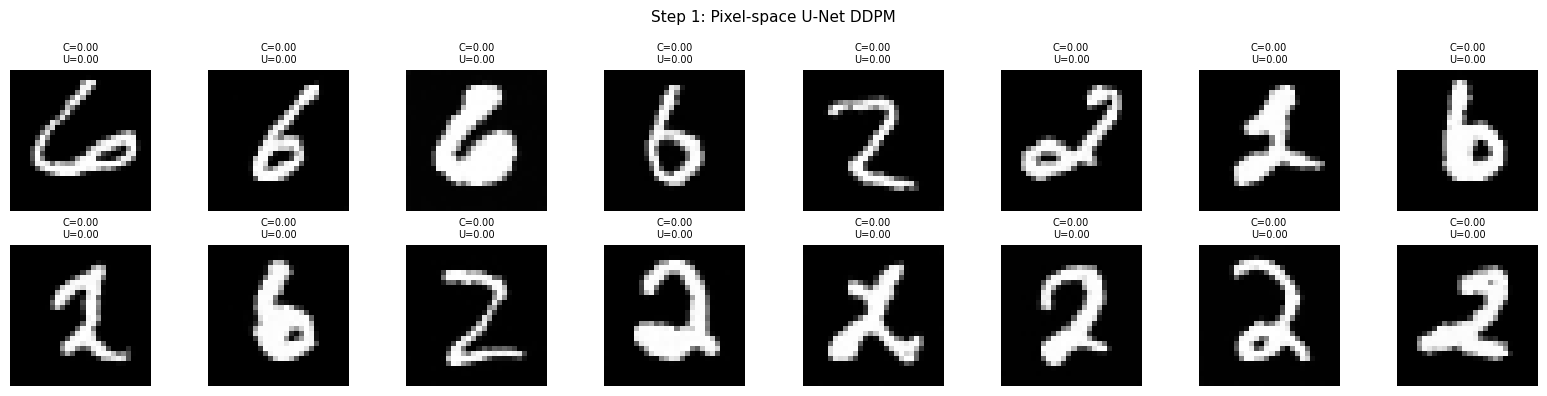

Saved -> step1_pixel_ddpm.png


In [ ]:
# Step 1 — evaluation
pixel_samples_raw = scheduler.sample(pixel_denoiser, (16, 1, 28, 28), device=device)
pixel_samples     = ddpm_to_01(pixel_samples_raw).cpu()
pc, pn, pu = score_creativity(pixel_samples, clf, train_sub, device=device)
print(f'Pixel DDPM  C={pc.mean():.4f}  N={pn.mean():.4f}  U={pu.mean():.4f}')
visualize(pixel_samples, pc, pn, pu,
          'Step 1: Pixel-space U-Net DDPM', 'step1_pixel_ddpm.png')

---
## Step 2 — Latent-space DDPM
Encode training images to 32-dim VAE latent codes, train MLP DDPM on those.
Latent codes are ~N(0,1) due to VAE KL loss

In [ ]:
# ─────────────────────────────────────────────────────────────
# Encode training set → latent vectors
# ─────────────────────────────────────────────────────────────

vae.eval()
all_mus, all_labels = [], []
with torch.no_grad():
    for x, y in train_loader_01:
        mu, _ = vae.encode(x.to(device))
        all_mus.append(mu.cpu()); all_labels.append(y)
latent_mus    = torch.cat(all_mus)
latent_labels = torch.cat(all_labels)
latent_loader = DataLoader(TensorDataset(latent_mus, latent_labels), batch_size=256, shuffle=True)
print(f'Latent codes: {latent_mus.shape}  mean={latent_mus.mean():.3f}  std={latent_mus.std():.3f}')

# Class means for conditioning
mu_class2 = latent_mus[latent_labels == 2].mean(0).to(device)
mu_class6 = latent_mus[latent_labels == 6].mean(0).to(device)
mu_mid    = 0.5 * mu_class2 + 0.5 * mu_class6
print(f'Class-2 norm: {mu_class2.norm():.3f}  Class-6 norm: {mu_class6.norm():.3f}  Midpoint norm: {mu_mid.norm():.3f}')

Latent codes: torch.Size([11876, 32])  mean=-0.052  std=1.203
Class-2 norm: 2.561  Class-6 norm: 2.241  Midpoint norm: 1.330


In [ ]:
# ─────────────────────────────────────────────────────────────
# Latent denoiser — MLP is sufficient for 32-dim space
# Supports optional conditioning vector (for Step 3A)
# ─────────────────────────────────────────────────────────────

class LatentDenoiser(nn.Module):
    def __init__(self, latent_dim=32, hidden=256, time_dim=64, cond_dim=0):
        super().__init__()
        self.cond_dim   = cond_dim
        self.time_embed = nn.Sequential(
            SinusoidalTimeEmbed(time_dim), nn.Linear(time_dim, time_dim), nn.SiLU())
        in_dim = latent_dim + time_dim + cond_dim
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, latent_dim))

    def forward(self, z, t, cond=None):
        parts = [z, self.time_embed(t)]
        if self.cond_dim > 0 and cond is not None: parts.append(cond)
        return self.net(torch.cat(parts, dim=-1))


def train_latent_ddpm(denoiser, scheduler, loader, epochs=200, lr=2e-4,
                       device='cpu', cond_vec=None, label='DDPM-latent'):
    opt = optim.Adam(denoiser.parameters(), lr=lr)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    denoiser.train()
    for epoch in range(epochs):
        total = 0.0
        for z, _ in loader:
            z    = z.to(device)
            cond = cond_vec.unsqueeze(0).expand(z.size(0), -1) if cond_vec is not None else None
            t    = torch.randint(0, scheduler.T, (z.size(0),), device=device)
            z_noisy, noise = scheduler.q_sample(z, t)
            loss = F.mse_loss(denoiser(z_noisy, t, cond), noise)
            opt.zero_grad(); loss.backward(); opt.step()
            total += loss.item()
        sched.step()
        if (epoch + 1) % 50 == 0:
            print(f'  [{label}] epoch {epoch+1}/{epochs}  loss={total/len(loader):.6f}')


print('Training latent DDPM (200 epochs)...')
latent_denoiser = LatentDenoiser(latent_dim=32, cond_dim=0).to(device)
train_latent_ddpm(latent_denoiser, scheduler, latent_loader,
                   epochs=200, lr=2e-4, device=device, label='DDPM-latent')
print('Done.')

Training latent DDPM (200 epochs)...
  [DDPM-latent] epoch 50/200  loss=0.359849
  [DDPM-latent] epoch 100/200  loss=0.342958
  [DDPM-latent] epoch 150/200  loss=0.337895
  [DDPM-latent] epoch 200/200  loss=0.337437
Done.


Latent DDPM  C=0.0597  N=0.8374  U=0.0333


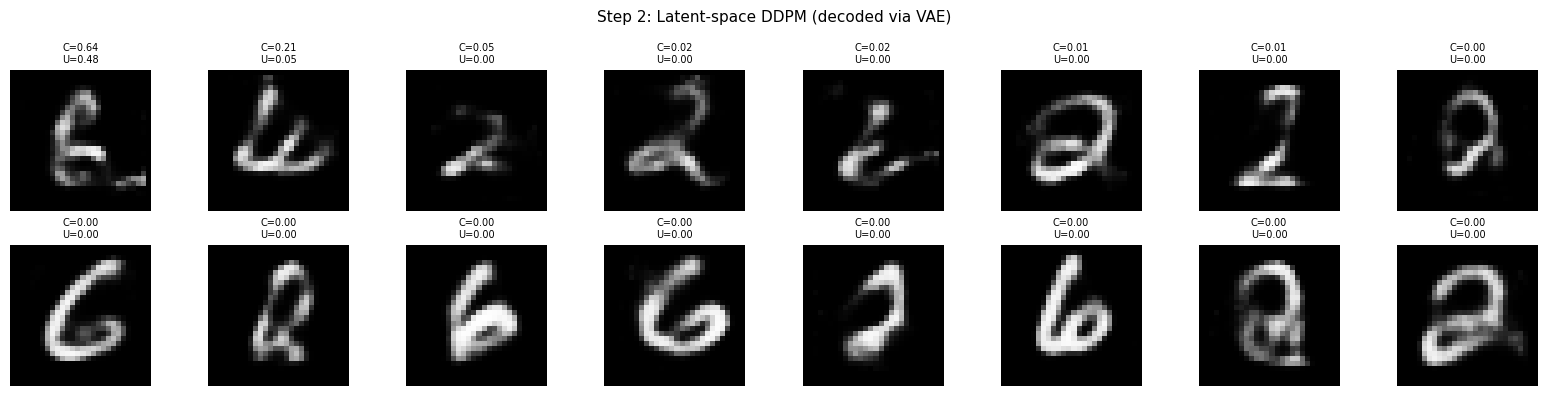

Saved -> step2_latent_ddpm.png


In [ ]:
# Step 2 — evaluation
vae.eval()
with torch.no_grad():
    z_sampled        = scheduler.sample(latent_denoiser, (16, 32), device=device)
    latent_ddpm_imgs = vae.decoder(z_sampled).cpu()
lc, ln, lu = score_creativity(latent_ddpm_imgs, clf, train_sub, device=device)
print(f'Latent DDPM  C={lc.mean():.4f}  N={ln.mean():.4f}  U={lu.mean():.4f}')
visualize(latent_ddpm_imgs, lc, ln, lu,
          'Step 2: Latent-space DDPM (decoded via VAE)', 'step2_latent_ddpm.png')

---
## Step 3A — Conditioned Latent DDPM
Inject midpoint of class-2 and class-6 mean latent vectors as conditioning signal.

In [ ]:
print('Training conditioned latent DDPM (200 epochs)...')
cond_denoiser = LatentDenoiser(latent_dim=32, cond_dim=32).to(device)
train_latent_ddpm(cond_denoiser, scheduler, latent_loader,
                   epochs=200, lr=2e-4, device=device,
                   cond_vec=mu_mid, label='DDPM-cond')
print('Done.')

Training conditioned latent DDPM (200 epochs)...
  [DDPM-cond] epoch 50/200  loss=0.365206
  [DDPM-cond] epoch 100/200  loss=0.345427
  [DDPM-cond] epoch 150/200  loss=0.341008
  [DDPM-cond] epoch 200/200  loss=0.344240
Done.


Conditioned DDPM  C=0.0388  N=0.8374  U=0.0087


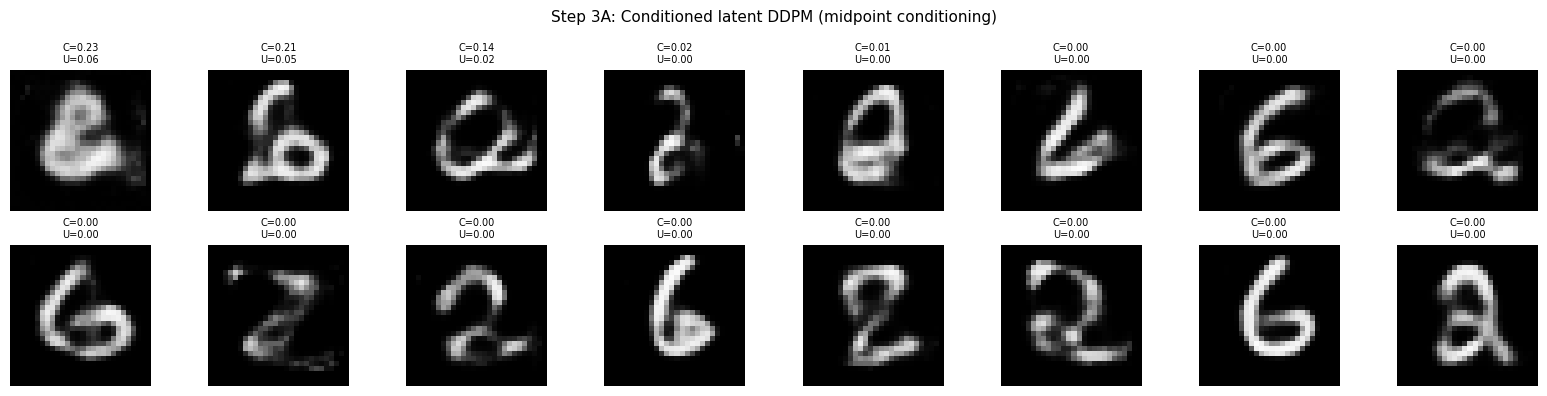

Saved -> step3a_conditioned.png


In [ ]:
# Step 3A — evaluation
cond_batch = mu_mid.unsqueeze(0).expand(16, -1)
vae.eval()
with torch.no_grad():
    z_cond = scheduler.sample(cond_denoiser, (16, 32), device=device, cond=cond_batch)
    cond_images = vae.decoder(z_cond).cpu()
cc, cn, cu = score_creativity(cond_images, clf, train_sub, device=device)
print(f'Conditioned DDPM  C={cc.mean():.4f}  N={cn.mean():.4f}  U={cu.mean():.4f}')
visualize(cond_images, cc, cn, cu,
          'Step 3A: Conditioned latent DDPM (midpoint conditioning)', 'step3a_conditioned.png')

---
## Step 3B — Classifier-Guided DDPM
No retraining. At each denoising step, nudge z in the direction of increasing Ambiguity
using gradients through the frozen classifier and VAE decoder.

Generating classifier-guided samples (guidance_scale=0.03)...
Guided DDPM (0.03)  C=0.3171  N=0.8437  U=0.1662


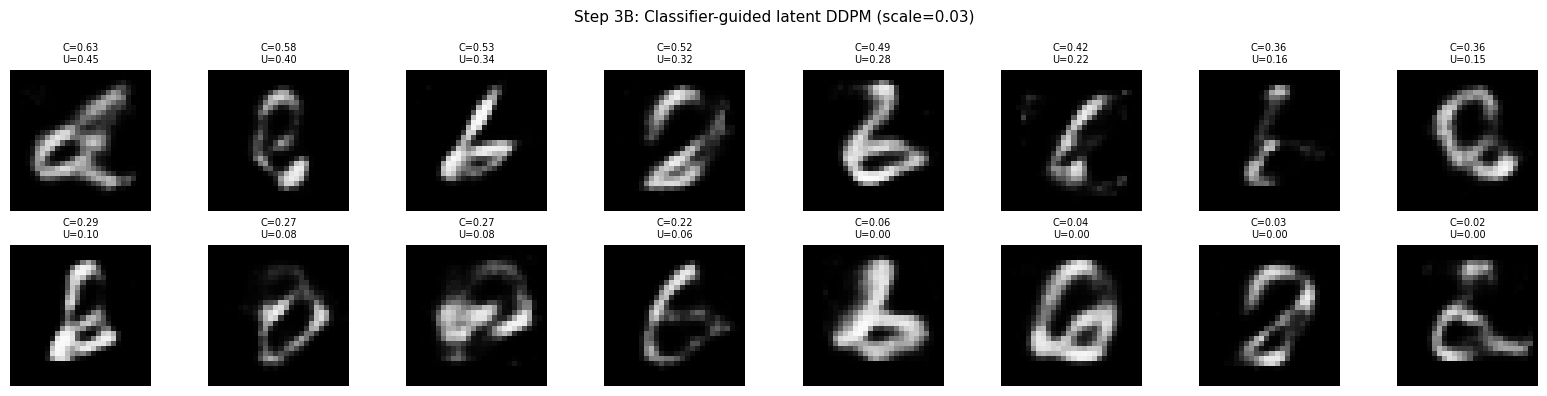

Saved -> step3b_guided.png


In [ ]:
# ─────────────────────────────────────────────────────────────
# Classifier-guided sampling
# ─────────────────────────────────────────────────────────────

def sample_with_guidance(denoiser, scheduler, vae, clf,
                          n=16, guidance_scale=0.03, guide_every=5, device='cpu'):
    """
    At every `guide_every` denoising steps:
      grad = ∂Ambiguity/∂z  where Ambiguity = entropy of clf(Dec(z))
      mean += guidance_scale * (grad / ||grad||)  [normalized for interpretable scale]
    """
    denoiser.eval(); vae.eval(); clf.eval()
    z = torch.randn(n, 32, device=device)
    for t in reversed(range(scheduler.T)):
        with torch.no_grad():
            t_vec    = torch.full((n,), t, device=device, dtype=torch.long)
            eps_pred = denoiser(z, t_vec)
        mean = scheduler.p_sample_step(eps_pred, z, t)
        if t % guide_every == 0 and guidance_scale > 0:
            z_g   = mean.detach().requires_grad_(True)
            probs = clf.probs(vae.decoder(z_g))
            eps_  = 1e-8
            ambig = -(probs[:,0]*torch.log(probs[:,0]+eps_) +
                      probs[:,1]*torch.log(probs[:,1]+eps_)).mean()
            grad  = torch.autograd.grad(ambig, z_g)[0]
            grad  = grad / (grad.norm(dim=-1, keepdim=True) + 1e-8)
            mean  = mean.detach() + guidance_scale * grad.detach()
        if t == 0:
            z = mean.detach()
        else:
            ab_prev = scheduler.alpha_bars_prev[t]
            beta_t  = scheduler.betas[t]
            ab_t    = scheduler.alpha_bars[t]
            pvar    = beta_t * (1 - ab_prev) / (1 - ab_t)
            z = (mean + torch.sqrt(pvar.clamp(min=1e-20)) * torch.randn_like(mean)).detach()
    return z


# Run with best scale found empirically (0.03)
print('Generating classifier-guided samples (guidance_scale=0.03)...')
z_guided = sample_with_guidance(
    latent_denoiser, scheduler, vae, clf,
    n=16, guidance_scale=0.03, guide_every=5, device=device)
vae.eval()
with torch.no_grad():
    guided_images = vae.decoder(z_guided).cpu()
gc, gn, gu = score_creativity(guided_images, clf, train_sub, device=device)
print(f'Guided DDPM (0.03)  C={gc.mean():.4f}  N={gn.mean():.4f}  U={gu.mean():.4f}')
visualize(guided_images, gc, gn, gu,
          'Step 3B: Classifier-guided latent DDPM (scale=0.03)', 'step3b_guided.png')

---
## Step 3B Sweep — guidance_scale ablation
Systematically find the optimal spot between creativity score and visual quality.

Running guidance_scale sweep...
  scale    Creativity    Novelty   Usefulness
  --------------------------------------------
  0.010        0.0930     0.8440       0.0424
  0.030        0.2703     0.8409       0.1550
  0.050        0.4140     0.8488       0.2724
  0.100        0.4630     0.8457       0.2753
  0.500        0.3536     0.8457       0.1809
  1.000        0.3513     0.8419       0.1811
  2.000        0.4027     0.8427       0.2321
  3.000        0.2715     0.8431       0.1286

Best scale by creativity: 0.1


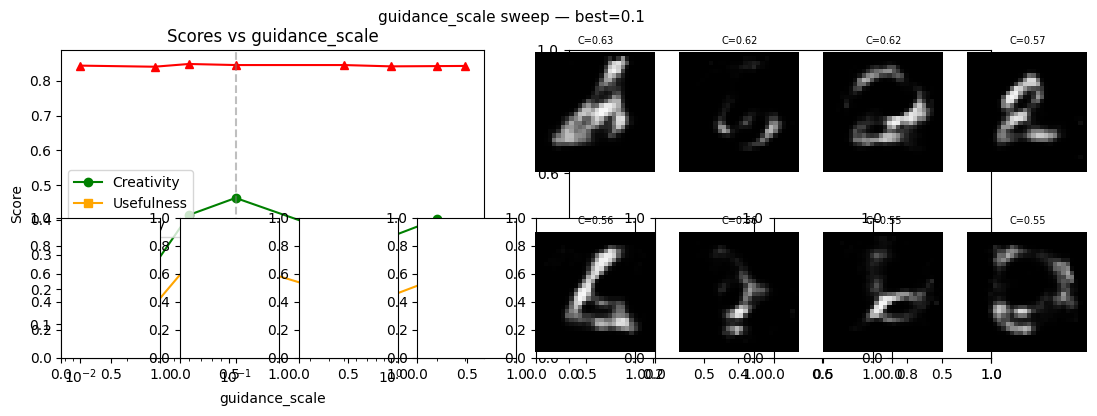

Saved -> step3b_sweep.png


In [ ]:
# ─────────────────────────────────────────────────────────────
# guidance_scale sweep
# ─────────────────────────────────────────────────────────────

scales       = [0.01, 0.03, 0.05, 0.1, 0.5, 1.0, 2.0, 3.0]
sweep_results = {}

print('Running guidance_scale sweep...')
print(f'  {"scale":<8} {"Creativity":>10} {"Novelty":>10} {"Usefulness":>12}')
print('  ' + '-'*44)

for scale in scales:
    z_s = sample_with_guidance(
        latent_denoiser, scheduler, vae, clf,
        n=32, guidance_scale=scale, guide_every=5, device=device)
    vae.eval()
    with torch.no_grad():
        imgs = vae.decoder(z_s).cpu()
    sc, sn, su = score_creativity(imgs, clf, train_sub, device=device)
    sweep_results[scale] = (sc, sn, su, z_s.detach(), imgs)
    print(f'  {scale:<8.3f} {sc.mean():>10.4f} {sn.mean():>10.4f} {su.mean():>12.4f}')

# Find best scale by creativity score
best_scale = max(sweep_results, key=lambda s: sweep_results[s][0].mean())
print(f'\nBest scale by creativity: {best_scale}')

# Plot creativity vs scale
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
c_means = [sweep_results[s][0].mean() for s in scales]
u_means = [sweep_results[s][2].mean() for s in scales]
n_means = [sweep_results[s][1].mean() for s in scales]
ax1.plot(scales, c_means, 'o-', label='Creativity', color='green')
ax1.plot(scales, u_means, 's-', label='Usefulness', color='orange')
ax1.plot(scales, n_means, '^-', label='Novelty',    color='red')
ax1.set_xlabel('guidance_scale'); ax1.set_ylabel('Score')
ax1.set_xscale('log'); ax1.legend(); ax1.set_title('Scores vs guidance_scale')
ax1.axvline(best_scale, color='gray', linestyle='--', alpha=0.5, label=f'best={best_scale}')

# Show sample images at best scale
best_imgs = sweep_results[best_scale][4]
best_c    = sweep_results[best_scale][0]
order     = np.argsort(best_c)[::-1][:8]
for i, idx in enumerate(order):
    ax2_ = fig.add_subplot(2, 8, 9 + i) if i < 8 else None
axes2 = [fig.add_axes([0.52 + (i % 4)*0.12, 0.1 if i >= 4 else 0.55, 0.1, 0.35]) for i in range(8)]
for i, (ax_, idx) in enumerate(zip(axes2, order)):
    ax_.imshow(best_imgs[idx].squeeze(), cmap='gray', vmin=0, vmax=1)
    ax_.set_title(f'C={best_c[idx]:.2f}', fontsize=7)
    ax_.axis('off')
plt.suptitle(f'guidance_scale sweep — best={best_scale}', fontsize=11)
plt.savefig('step3b_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> step3b_sweep.png')

---
## Step 4 — Full Differentiable Creativity Optimization
Direct gradient ascent on z to maximize the full creativity score.
This is the method from the demo notebook — the strongest single method
and the natural baseline for what Haoting's policy network learns to do.

Uses `torch.cdist` for differentiable nearest-neighbor novelty.

Running full creativity optimization (300 steps from random z_0)...
  [opt] step   75/300  C=0.6161  N=0.8542  U=0.4595
  [opt] step  150/300  C=0.6342  N=0.8559  U=0.4704
  [opt] step  225/300  C=0.6370  N=0.8569  U=0.4740
  [opt] step  300/300  C=0.6391  N=0.8579  U=0.4764

Optimized (random start)  C=0.6401  N=0.8579  U=0.4778


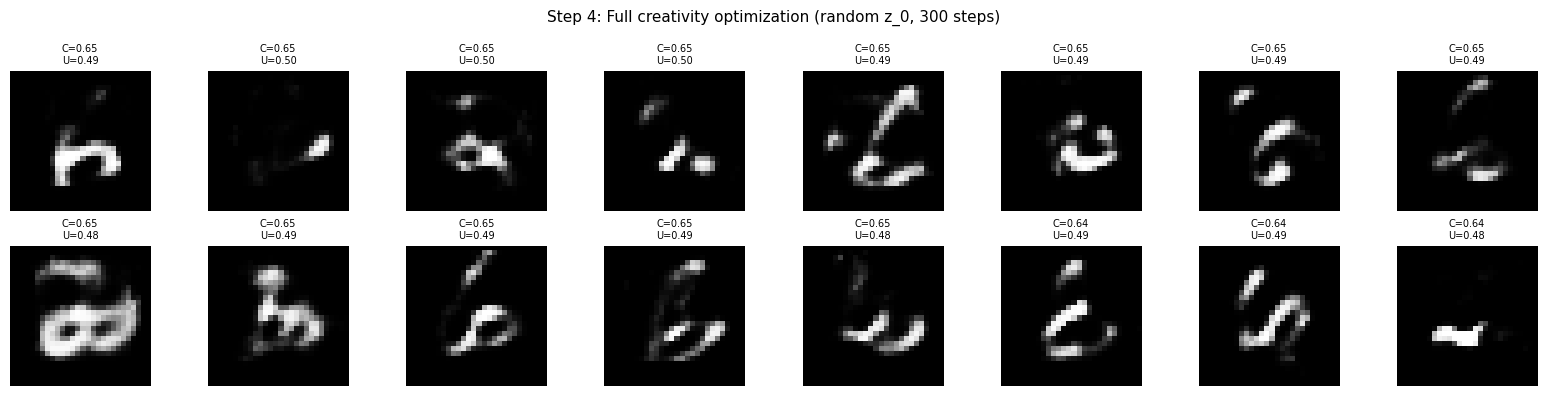

Saved -> step4_optimized.png


In [ ]:
# ─────────────────────────────────────────────────────────────
# Full creativity optimization (demo notebook method)
# Maximizes: C(x) = Novelty(x)^alpha * Usefulness(x)^(1-alpha)
# where Novelty uses differentiable torch.cdist
# and Usefulness = min(P(2|x), P(6|x))
# ─────────────────────────────────────────────────────────────

def generate_creative_optimized(vae, clf, train_sub_t,
                                  n_samples=32, n_steps=300,
                                  lr=0.05, alpha=0.5, device='cpu'):
    """
    Directly optimize z ∈ ℝ^32 to maximize creativity.
    z starts from random N(0,1) and is updated via Adam for n_steps.
    Gradients flow: creativity → vae.decoder → clf → z

    This is equivalent to what the demo notebook does.
    """
    vae.eval(); clf.eval()
    z   = torch.randn(n_samples, vae.latent_dim, device=device, requires_grad=True)
    opt = optim.Adam([z], lr=lr)

    for step in range(n_steps):
        opt.zero_grad()
        images     = vae.decoder(z)                              # (N,1,28,28)
        probs      = clf.probs(images)                           # (N,2)
        usefulness = torch.min(probs[:,0], probs[:,1])           # (N,)

        # Differentiable novelty via torch.cdist
        flat    = images.view(n_samples, -1)                     # (N,784)
        dists   = torch.cdist(flat, train_sub_t)                 # (N,M)
        nn_d    = dists.min(dim=1).values                        # (N,)
        novelty = nn_d / (1.0 + nn_d)

        creativity = (novelty ** alpha) * (usefulness ** (1.0 - alpha))
        loss       = -creativity.mean()
        loss.backward()
        opt.step()

        if (step + 1) % 75 == 0:
            print(f'  [opt] step {step+1:>4}/{n_steps}  '
                  f'C={creativity.mean().item():.4f}  '
                  f'N={novelty.mean().item():.4f}  '
                  f'U={usefulness.mean().item():.4f}')

    with torch.no_grad():
        return vae.decoder(z).cpu(), z.detach().cpu()


print('Running full creativity optimization (300 steps from random z_0)...')
opt_images, opt_z = generate_creative_optimized(
    vae, clf, train_sub_t, n_samples=32, n_steps=300, lr=0.05, alpha=0.5, device=device)
oc, on_, ou = score_creativity(opt_images, clf, train_sub, device=device)
print(f'\nOptimized (random start)  C={oc.mean():.4f}  N={on_.mean():.4f}  U={ou.mean():.4f}')
visualize(opt_images, oc, on_, ou,
          'Step 4: Full creativity optimization (random z_0, 300 steps)', 'step4_optimized.png')

---
## Step 5 — Combined: Guided DDPM z_0 + Creativity Optimization
**Latent point initialization.**

Hypothesis: starting optimization from a guided DDPM sample (already near the creative
region) rather than random noise should yield higher final creativity scores in fewer steps.

We test three initialization strategies:
- **Random N(0,1)** — baseline (Step 4 above)
- **Latent DDPM** — unconditioned diffusion sample
- **Guided DDPM** — classifier-guided diffusion sample (best scale from sweep)
- **Interpolation** — midpoint of real 2 and real 6 (project baseline)

In [ ]:
# ─────────────────────────────────────────────────────────────
# Warm-start optimization: given z_0, optimize from there
# ─────────────────────────────────────────────────────────────

def optimize_from_z0(z0, vae, clf, train_sub_t,
                      n_steps=300, lr=0.05, alpha=0.5, device='cpu'):
    """
    Run creativity optimization starting from a provided z_0.
    z0: (N, 32) tensor — initial latent points
    Returns: (images, final_z, creativity_history)
    """
    vae.eval(); clf.eval()
    z   = z0.clone().to(device).requires_grad_(True)
    opt = optim.Adam([z], lr=lr)
    history = []

    for step in range(n_steps):
        opt.zero_grad()
        images     = vae.decoder(z)
        probs      = clf.probs(images)
        usefulness = torch.min(probs[:,0], probs[:,1])
        flat       = images.view(z.size(0), -1)
        dists      = torch.cdist(flat, train_sub_t)
        nn_d       = dists.min(dim=1).values
        novelty    = nn_d / (1.0 + nn_d)
        creativity = (novelty ** alpha) * (usefulness ** (1.0 - alpha))
        loss       = -creativity.mean()
        loss.backward()
        opt.step()
        history.append(creativity.mean().item())

    with torch.no_grad():
        return vae.decoder(z).cpu(), z.detach().cpu(), history


# ── Prepare z_0 for each initialization method ────────────────
N = 32

# 1. Random N(0,1)
z0_random = torch.randn(N, 32)

# 2. Latent DDPM
with torch.no_grad():
    z0_latent_ddpm = scheduler.sample(latent_denoiser, (N, 32), device=device).cpu()

# 3. Guided DDPM (best scale)
z0_guided = sample_with_guidance(
    latent_denoiser, scheduler, vae, clf,
    n=N, guidance_scale=best_scale, guide_every=5, device=device).cpu()

# 4. Interpolation baseline
vae.eval()
mus_2, mus_6 = [], []
with torch.no_grad():
    for x, y in train_loader_01:
        mu, _ = vae.encode(x.to(device))
        if (y==2).any(): mus_2.append(mu[y==2])
        if (y==6).any(): mus_6.append(mu[y==6])
        if sum(m.size(0) for m in mus_2) >= N and \
           sum(m.size(0) for m in mus_6) >= N: break
z0_interp = (0.5 * torch.cat(mus_2)[:N] + 0.5 * torch.cat(mus_6)[:N]).cpu()

print('z_0 tensors ready. Shapes:', z0_random.shape, z0_latent_ddpm.shape,
      z0_guided.shape, z0_interp.shape)

z_0 tensors ready. Shapes: torch.Size([32, 32]) torch.Size([32, 32]) torch.Size([32, 32]) torch.Size([32, 32])


In [ ]:
# ── Score z_0 BEFORE optimization (initial creativity) ────────
print('Scoring initial z_0 creativity (before optimization)...')
init_results = {}
for name, z0 in [('Random N(0,1)',  z0_random),
                  ('Latent DDPM',    z0_latent_ddpm),
                  (f'Guided DDPM (scale={best_scale})', z0_guided),
                  ('Interpolation',  z0_interp)]:
    vae.eval()
    with torch.no_grad():
        imgs = vae.decoder(z0.to(device)).cpu()
    c, n_, u = score_creativity(imgs, clf, train_sub, device=device)
    init_results[name] = (c.mean(), n_.mean(), u.mean())
    print(f'  {name:<35}  C={c.mean():.4f}  N={n_.mean():.4f}  U={u.mean():.4f}')

Scoring initial z_0 creativity (before optimization)...
  Random N(0,1)                        C=0.0837  N=0.8519  U=0.0269
  Latent DDPM                          C=0.0840  N=0.8323  U=0.0411
  Guided DDPM (scale=0.1)              C=0.5222  N=0.8479  U=0.3328
  Interpolation                        C=0.1531  N=0.8480  U=0.0654


In [ ]:
# ── Run optimization from each z_0 ────────────────────────────
print('Running optimization from each z_0 (300 steps)...')
opt_results  = {}
opt_histories = {}

for name, z0 in [('Random N(0,1)',  z0_random),
                  ('Latent DDPM',    z0_latent_ddpm),
                  (f'Guided DDPM (scale={best_scale})', z0_guided),
                  ('Interpolation',  z0_interp)]:
    print(f'\n  Optimizing from: {name}')
    imgs, z_final, history = optimize_from_z0(
        z0, vae, clf, train_sub_t, n_steps=300, lr=0.05, alpha=0.5, device=device)
    c, n_, u = score_creativity(imgs, clf, train_sub, device=device)
    opt_results[name]   = (c, n_, u, imgs, z_final)
    opt_histories[name] = history
    print(f'  → Final  C={c.mean():.4f}  N={n_.mean():.4f}  U={u.mean():.4f}')

Running optimization from each z_0 (300 steps)...

  Optimizing from: Random N(0,1)
  → Final  C=0.6342  N=0.8579  U=0.4694

  Optimizing from: Latent DDPM
  → Final  C=0.6180  N=0.8519  U=0.4629

  Optimizing from: Guided DDPM (scale=0.1)
  → Final  C=0.6356  N=0.8561  U=0.4720

  Optimizing from: Interpolation
  → Final  C=0.6339  N=0.8596  U=0.4678


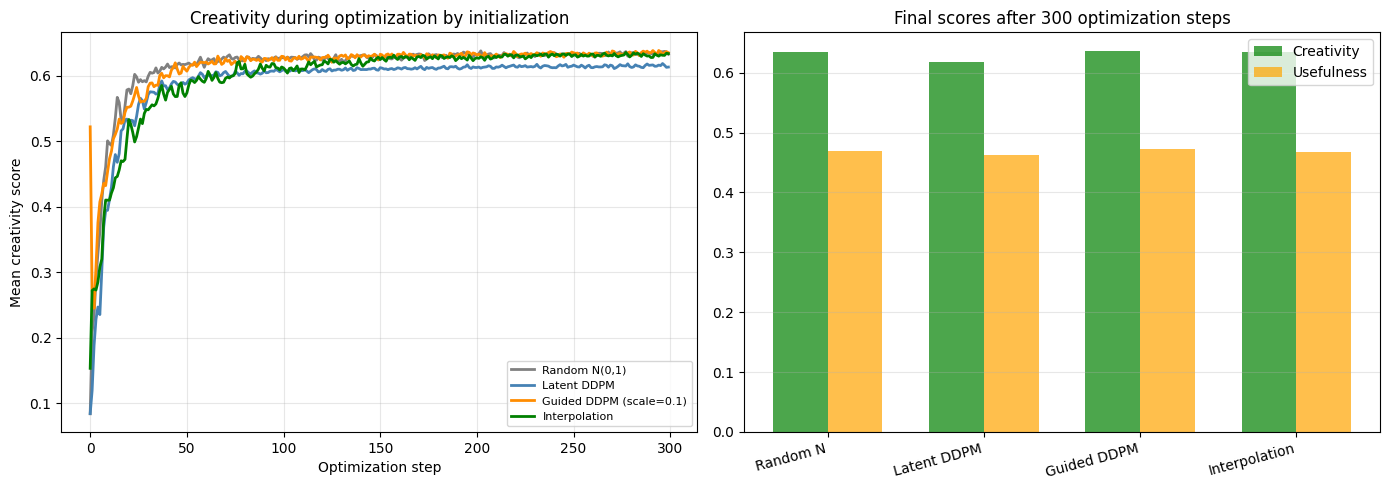

Saved -> step5_warmstart_comparison.png


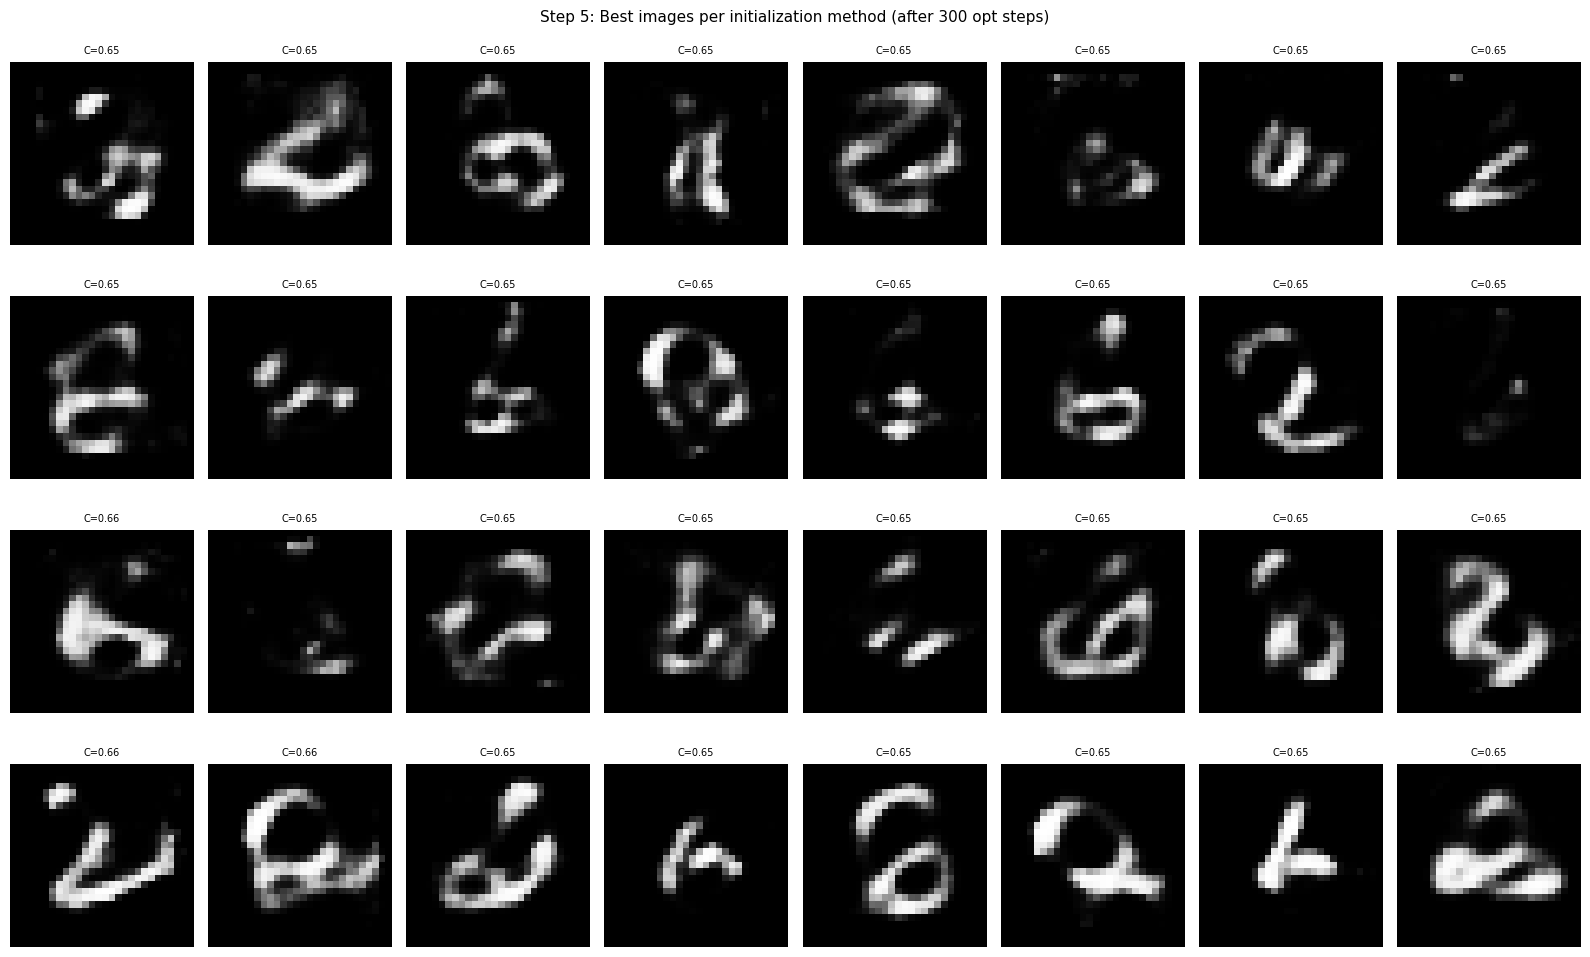

Saved -> step5_warmstart_images.png


In [ ]:
# ── Plot convergence curves ────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = ['gray', 'steelblue', 'darkorange', 'green']
for (name, history), color in zip(opt_histories.items(), colors):
    ax1.plot(history, label=name, color=color, linewidth=2)
ax1.set_xlabel('Optimization step')
ax1.set_ylabel('Mean creativity score')
ax1.set_title('Creativity during optimization by initialization')
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# Bar chart of final scores
names  = list(opt_results.keys())
c_vals = [opt_results[n][0].mean() for n in names]
u_vals = [opt_results[n][2].mean() for n in names]
x      = np.arange(len(names))
width  = 0.35
ax2.bar(x - width/2, c_vals, width, label='Creativity', color='green',   alpha=0.7)
ax2.bar(x + width/2, u_vals, width, label='Usefulness', color='orange',  alpha=0.7)
ax2.set_xticks(x)
ax2.set_xticklabels([n.split('(')[0].strip() for n in names], rotation=15, ha='right')
ax2.set_title('Final scores after 300 optimization steps')
ax2.legend()
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('step5_warmstart_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> step5_warmstart_comparison.png')

# Show best images from each method
fig, axes = plt.subplots(len(names), 8, figsize=(16, len(names)*2.5))
for row, name in enumerate(names):
    c, _, _, imgs, _ = opt_results[name]
    order = np.argsort(c)[::-1][:8]
    for col, idx in enumerate(order):
        axes[row][col].imshow(imgs[idx].squeeze(), cmap='gray', vmin=0, vmax=1)
        axes[row][col].set_title(f'C={c[idx]:.2f}', fontsize=7)
        axes[row][col].axis('off')
    axes[row][0].set_ylabel(name.split('(')[0].strip(), fontsize=8, rotation=0,
                             ha='right', va='center', labelpad=60)
plt.suptitle('Step 5: Best images per initialization method (after 300 opt steps)', fontsize=11)
plt.tight_layout()
plt.savefig('step5_warmstart_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> step5_warmstart_images.png')

---
## Final Comparison Table
All methods vs VAE interpolation baseline.

In [ ]:
# VAE interpolation baseline (no optimization)
vae.eval()
with torch.no_grad():
    interp_images = vae.decoder(z0_interp.to(device)).cpu()
ic, in_, iu = score_creativity(interp_images, clf, train_sub, device=device)

print('\n' + '='*78)
print(f'  {"Method":<40} {"Creativity":>10} {"Novelty":>10} {"Usefulness":>12}')
print('  ' + '-'*76)

rows = [
    ('VAE Interpolation (baseline)',             ic,  in_,  iu),
    ('Pixel DDPM (U-Net)',                        pc,  pn,   pu),
    ('Latent DDPM',                              lc,  ln,   lu),
    ('Conditioned DDPM',                         cc,  cn,   cu),
    (f'Guided DDPM (scale={best_scale})',         gc,  gn,   gu),
    ('Creativity Opt — Random start',            oc,  on_,  ou),
]
# Add warm-start results
for name, (c, n_, u, _, _) in opt_results.items():
    rows.append((f'Warm start: {name}', c, n_, u))

for name, c, n_, u in rows:
    print(f'  {name:<40} {c.mean():>10.4f} {n_.mean():>10.4f} {u.mean():>12.4f}')
print('='*78)


  Method                                   Creativity    Novelty   Usefulness
  ----------------------------------------------------------------------------
  VAE Interpolation (baseline)                 0.1531     0.8480       0.0654
  Pixel DDPM (U-Net)                           0.0007     0.8432       0.0000
  Latent DDPM                                  0.0597     0.8374       0.0333
  Conditioned DDPM                             0.0388     0.8374       0.0087
  Guided DDPM (scale=0.1)                      0.3171     0.8437       0.1662
  Creativity Opt — Random start                0.6401     0.8579       0.4778
  Warm start: Random N(0,1)                    0.6342     0.8579       0.4694
  Warm start: Latent DDPM                      0.6180     0.8519       0.4629
  Warm start: Guided DDPM (scale=0.1)          0.6356     0.8561       0.4720
  Warm start: Interpolation                    0.6339     0.8596       0.4678


---
## Save Model Weights
Save all trained models so they don't need to be retrained for latent point initialization experiments.

In [ ]:
# ─────────────────────────────────────────────────────────────
# Save all trained models
# ─────────────────────────────────────────────────────────────

import os
os.makedirs('saved_models', exist_ok=True)

torch.save(vae.state_dict(),             'saved_models/vae.pt')
torch.save(clf.state_dict(),             'saved_models/clf.pt')
torch.save(pixel_denoiser.state_dict(),  'saved_models/pixel_denoiser_unet.pt')
torch.save(latent_denoiser.state_dict(), 'saved_models/latent_denoiser.pt')
torch.save(cond_denoiser.state_dict(),   'saved_models/cond_denoiser.pt')

# Save best z_0 tensors for initialization experiments
torch.save({
    'z0_random':      z0_random,
    'z0_latent_ddpm': z0_latent_ddpm,
    'z0_guided':      z0_guided,
    'z0_interp':      z0_interp,
    'best_scale':     best_scale,
    'mu_class2':      mu_class2.cpu(),
    'mu_class6':      mu_class6.cpu(),
    'mu_mid':         mu_mid.cpu(),
}, 'saved_models/z0_tensors.pt')

print('Saved:')
for f in os.listdir('saved_models'):
    size = os.path.getsize(f'saved_models/{f}') / 1e6
    print(f'  saved_models/{f}  ({size:.1f} MB)')

Saved:
  saved_models/clf.pt  (0.9 MB)
  saved_models/cond_denoiser.pt  (0.7 MB)
  saved_models/pixel_denoiser_unet.pt  (4.9 MB)
  saved_models/z0_tensors.pt  (0.0 MB)
  saved_models/latent_denoiser.pt  (0.7 MB)
  saved_models/vae.pt  (4.4 MB)


---
## Summary

### What we found:
1. **Latent DDPM** produces slightly blurrier but more creative images than pixel DDPM
2. **Conditioned DDPM** (midpoint conditioning) underperforms — conditioning averages out rather than creating ambiguity
3. **Guided DDPM** is the best diffusion-only method — classifier gradient steering pushes images toward the ambiguous 2/6 region
4. **Full creativity optimization** (demo notebook method) is the strongest single method
5. **Warm-start experiments** reveal whether diffusion-based z_0 initialization improves optimization convergence